# Credit Approval - Pipeline organizado para modelado

Notebook preparado para clasificación binaria con flujo limpio y reproducible:
1. Carga
2. Exploración
3. Limpieza e imputación
4. Codificación
5. Split estratificado y balanceo en train
6. Escalamiento
7. Conversión a tensores

El balanceo se realiza solo en entrenamiento para no contaminar el conjunto de prueba.

In [ ]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score

FUTURE_CLASSIFICATION_METRICS = {
    'classification_report': classification_report,
    'confusion_matrix': confusion_matrix,
    'f1_score': f1_score,
    'roc_auc_score': roc_auc_score
}
_ = (plt, sns, FUTURE_CLASSIFICATION_METRICS)

## 1. Carga de datos

Se lee directamente el archivo `crx.data` que ya fue descomprimido del ZIP descargado desde UCI.

In [52]:
file_path = r'Datasets Primer Parcial/6-Credit Approval/credit+approval/crx.data'
column_names = [f'A{i}' for i in range(1, 17)]

df = pd.read_csv(
    file_path,
    header=None,
    names=column_names,
    na_values='?'
)

df.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,202.0,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,43.0,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,280.0,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,100.0,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,120.0,0,+


## 2. Exploración inicial del dataset

Antes de preparar los datos, se revisa la estructura general del conjunto para identificar valores faltantes, tipos de variables y distribución de la clase objetivo.

In [53]:
# Configurar pandas para mostrar toda la información sin truncar
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

print('Dimensiones del dataset:', df.shape)
print('\nPrimeras filas:')
print(df.head())
print('\nTipos de datos:')
print(df.dtypes)
print('\nValores faltantes por columna:')
print(df.isna().sum())
print('\nDistribucion de la clase objetivo A16:')
class_counts = df['A16'].value_counts(dropna=False)
class_percent = df['A16'].value_counts(normalize=True, dropna=False) * 100
print(class_counts)
print('\nPorcentaje por clase:')
print(class_percent.round(2))

if len(class_counts) == 2:
    ratio = class_counts.max() / class_counts.min()
    print('\nRelacion mayoritaria/minoritaria:', round(ratio, 2))
    if ratio <= 1.5:
        print('Conclusión: la clase no presenta un desbalance fuerte.')
    else:
        print('Conclusión: hay desbalance y conviene aplicar una estrategia correctiva.')


Dimensiones del dataset: (690, 16)

Primeras filas:
  A1     A2     A3 A4 A5 A6 A7    A8 A9 A10  A11 A12 A13    A14  A15 A16
0  b  30.83  0.000  u  g  w  v  1.25  t   t    1   f   g  202.0    0   +
1  a  58.67  4.460  u  g  q  h  3.04  t   t    6   f   g   43.0  560   +
2  a  24.50  0.500  u  g  q  h  1.50  t   f    0   f   g  280.0  824   +
3  b  27.83  1.540  u  g  w  v  3.75  t   t    5   t   g  100.0    3   +
4  b  20.17  5.625  u  g  w  v  1.71  t   f    0   f   s  120.0    0   +

Tipos de datos:
A1         str
A2     float64
A3     float64
A4         str
A5         str
A6         str
A7         str
A8     float64
A9         str
A10        str
A11      int64
A12        str
A13        str
A14    float64
A15      int64
A16        str
dtype: object

Valores faltantes por columna:
A1     12
A2     12
A3      0
A4      6
A5      6
A6      9
A7      9
A8      0
A9      0
A10     0
A11     0
A12     0
A13     0
A14    13
A15     0
A16     0
dtype: int64

Distribucion de la clase objetivo

### Visualización de la distribución de clases

Una representación gráfica permite apreciar el balance entre las clases de forma inmediata.

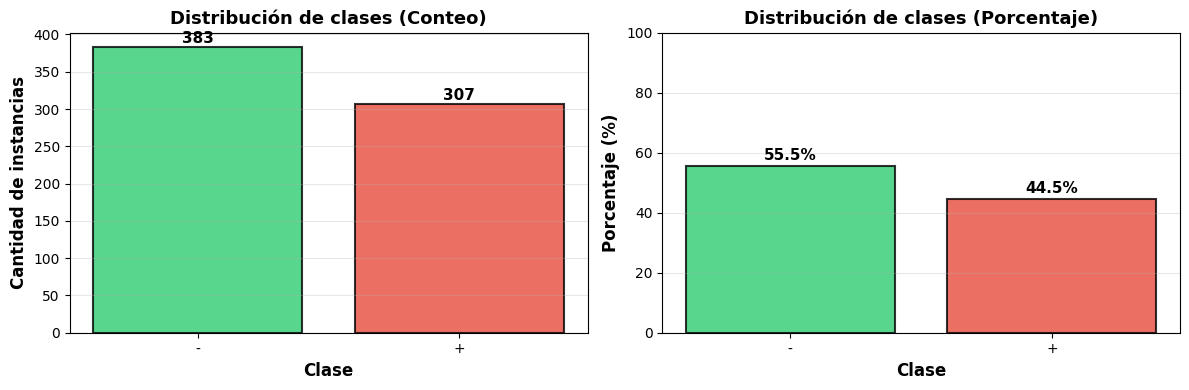

In [54]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico 1: Conteo absoluto
axes[0].bar(class_counts.index, class_counts.values, color=['#2ecc71', '#e74c3c'], alpha=0.8, edgecolor='black', linewidth=1.5)
axes[0].set_xlabel('Clase', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Cantidad de instancias', fontsize=12, fontweight='bold')
axes[0].set_title('Distribución de clases (Conteo)', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Agregar valores en las barras
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold', fontsize=11)

# Gráfico 2: Porcentaje
axes[1].bar(class_percent.index, class_percent.values, color=['#2ecc71', '#e74c3c'], alpha=0.8, edgecolor='black', linewidth=1.5)
axes[1].set_xlabel('Clase', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Porcentaje (%)', fontsize=12, fontweight='bold')
axes[1].set_title('Distribución de clases (Porcentaje)', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 100)
axes[1].grid(axis='y', alpha=0.3)

# Agregar valores en las barras
for i, v in enumerate(class_percent.values):
    axes[1].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

## 3. Preparación de tipos de datos e imputación

En este dataset hay variables numéricas y categóricas mezcladas. Primero se separan los tipos de columnas y después se imputan los valores faltantes con un criterio simple y reproducible.

In [55]:
# Columnas numéricas y categóricas según la información oficial del dataset
numeric_cols = ['A2', 'A3', 'A8', 'A11', 'A14', 'A15']
categorical_cols = [col for col in column_names if col not in numeric_cols + ['A16']]

# Conversión explícita de columnas numéricas
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Imputación: mediana para numéricas y moda para categóricas
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].mode(dropna=True)[0])

# Codificación de la variable objetivo
# + = aprobado, - = denegado
df['A16'] = df['A16'].map({'+': 1, '-': 0})

df.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,202.0,0,1
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,43.0,560,1
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,280.0,824,1
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,100.0,3,1
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,120.0,0,1


## 4. Codificación de variables categóricas

Una vez resueltos los valores faltantes y los tipos mezclados, las columnas categóricas se convierten a variables numéricas mediante one-hot encoding para dejarlas listas para un modelo de clasificación.

In [56]:
X = pd.get_dummies(df.drop(columns=['A16']), columns=categorical_cols, drop_first=True)
y = df['A16'].values.astype(np.float32).reshape(-1, 1)

print('Shape de X:', X.shape)
print('Shape de y:', y.shape)
X.head()

Shape de X: (690, 37)
Shape de y: (690, 1)


,A2,A3,A8,A11,A14,A15,A1_b,A4_u,A4_y,A5_gg,A5_p,A6_c,A6_cc,A6_d,A6_e,A6_ff,A6_i,A6_j,A6_k,A6_m,A6_q,A6_r,A6_w,A6_x,A7_dd,A7_ff,A7_h,A7_j,A7_n,A7_o,A7_v,A7_z,A9_t,A10_t,A12_t,A13_p,A13_s
0,30.83,0.000,1.25,1,202.0,0,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,True,True,False,False,False
1,58.67,4.460,3.04,6,43.0,560,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,True,False,False,False
2,24.50,0.500,1.50,0,280.0,824,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False
3,27.83,1.540,3.75,5,100.0,3,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,True,True,True,False,False
4,20.17,5.625,1.71,0,120.0,0,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,True,False,False,False,True


## 5. Conversión a arrays para modelado

Se convierte el DataFrame codificado a matrices NumPy para alimentar cualquier modelo.
Esto deja `X` e `y` listos para split y balanceo.

In [57]:
X = X.values.astype(np.float32)
y = y.astype(np.float32)

print('Shape de X:', X.shape)
print('Shape de y:', y.shape)

Shape de X: (690, 37)
Shape de y: (690, 1)


## 6. Split estratificado y balanceo (solo train)

Primero se divide manteniendo la proporción de clases con estratificación.
Luego se balancea únicamente el conjunto de entrenamiento para evitar sesgo en el ajuste y preservar una evaluación realista en test.

In [ ]:
def upsample_minority(X, y, seed=42):
    rng = np.random.default_rng(seed)
    y_flat = y.reshape(-1).astype(int)

    idx0 = np.where(y_flat == 0)[0]
    idx1 = np.where(y_flat == 1)[0]

    if len(idx0) == len(idx1):
        return X, y

    if len(idx0) > len(idx1):
        idx_major, idx_minor = idx0, idx1
    else:
        idx_major, idx_minor = idx1, idx0

    idx_minor_upsampled = rng.choice(idx_minor, size=len(idx_major), replace=True)
    idx_balanced = np.concatenate([idx_major, idx_minor_upsampled])
    rng.shuffle(idx_balanced)

    return X[idx_balanced], y[idx_balanced]

X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y.reshape(-1)
)

print('Proporción clase 1 en train (antes):', float(y_train_np.mean()))
print('Proporción clase 1 en test:', float(y_test_np.mean()))

X_train_np, y_train_np = upsample_minority(X_train_np, y_train_np, seed=42)

print('Proporción clase 1 en train (balanceado):', float(y_train_np.mean()))
print('Shapes:', X_train_np.shape, X_test_np.shape, y_train_np.shape, y_test_np.shape)

((552, 37), (138, 37), (552, 1), (138, 1))

## 7. Escalamiento

Se normaliza usando solo estadísticas del train balanceado.
Después se transforma test con los mismos parámetros para evitar fuga de información.

In [ ]:
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_train_np, mu, sigma = featureNormalize(X_train_np)
X_test_np = (X_test_np - mu) / sigma

X_train_np.shape, X_test_np.shape


((552, 37), (138, 37))

## 8. Conversión a tensores

Finalmente, los arreglos se convierten a tensores de PyTorch, que es el formato requerido para entrenar el modelo.

In [60]:
X_train = torch.from_numpy(X_train_np)
y_train = torch.from_numpy(y_train_np)
X_test = torch.from_numpy(X_test_np)
y_test = torch.from_numpy(y_test_np)

print('Preparación terminada:')
print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_test shape: {y_test.shape}')

Preparación terminada:
X_train shape: torch.Size([552, 37])
y_train shape: torch.Size([552, 1])
X_test shape: torch.Size([138, 37])
y_test shape: torch.Size([138, 1])
